# DistributionBuilder: LLM estimates -> flow maxent -> distributions

`maxent_sampler.DistributionBuilder` is the flow-sampler counterpart of
`maxent_smm.distribution_builder`: it takes the high-level `Variable` +
`Estimate` objects that the LLM elicitation pipeline produces, converts each
estimate into the sampler's constraint grammar, fits a `FlowSamplerModel` by
soft-constrained maximum entropy (**exact** joint entropy, fresh latents every
Adam step), and reads out `HistogramDistribution` / `BinaryDistribution`
marginals plus a per-estimate fit report.

**Sample query** (Metaculus 41370, from `metaculus/tiny_dataset.json`):

> *Will there be at least one podium sweep at the 2026 Winter Olympic Games?*

Market price at freeze: **0.90**. Resolved: **YES**.

The variables and estimates below are the *actual* cached output of
`VariableGenerator` / `NaturalEstimateGenerator` (gemini-3-flash) for this
question — inlined verbatim from `metaculus/llm_cache.json` so the notebook
needs no API key.

In [1]:
import os
os.environ.setdefault("JAX_PLATFORMS", "cpu")
import numpy as np
import matplotlib.pyplot as plt
from pydantic import TypeAdapter

from calibrated_response.models.query import EstimateUnion
from calibrated_response.models.variable import BinaryVariable, ContinuousVariable
from calibrated_response.maxent_sampler import DistributionBuilder, plot_pairwise

TARGET = "podium_sweep_occurrence"

variables = [
    BinaryVariable(name="podium_sweep_occurrence",
                   description="Whether there is at least one podium sweep at the 2026 Winter Olympic Games"),
    ContinuousVariable(name="total_sweeps_count",
                       description="The total number of podium sweeps that occur at the 2026 Winter Olympic Games",
                       lower_bound=0.0, upper_bound=12.0, unit="sweeps"),
    ContinuousVariable(name="netherlands_speed_skating_dominance",
                       description="Number of speed skating events where the Netherlands wins at least two medals",
                       lower_bound=0.0, upper_bound=14.0, unit="events"),
    ContinuousVariable(name="norway_cross_country_dominance",
                       description="Number of cross-country skiing events where Norway wins at least two medals",
                       lower_bound=0.0, upper_bound=12.0, unit="events"),
]

# the LLM's estimates, as serialized by the elicitation pipeline
_ESTIMATES_JSON = [
  {"id": "e0", "estimate_type": "probability",
   "proposition": {"proposition_type": "equality", "variable": "podium_sweep_occurrence",
                   "variable_type": "binary", "value": True},
   "probability": 0.88},
  {"id": "e1", "estimate_type": "expectation",
   "variable": "total_sweeps_count", "expected_value": 1.9},
  {"id": "e2", "estimate_type": "expectation",
   "variable": "netherlands_speed_skating_dominance", "expected_value": 5.5},
  {"id": "e3", "estimate_type": "expectation",
   "variable": "norway_cross_country_dominance", "expected_value": 6.0},
  {"id": "e4", "estimate_type": "conditional_probability",
   "proposition": {"proposition_type": "equality", "variable": "podium_sweep_occurrence",
                   "variable_type": "binary", "value": True},
   "conditions": [{"proposition_type": "inequality", "variable": "netherlands_speed_skating_dominance",
                   "variable_type": "continuous", "threshold": 7.0, "is_lower_bound": True}],
   "probability": 0.96},
  {"id": "e5", "estimate_type": "conditional_expectation",
   "variable": "total_sweeps_count",
   "conditions": [{"proposition_type": "inequality", "variable": "norway_cross_country_dominance",
                   "variable_type": "continuous", "threshold": 8.0, "is_lower_bound": True}],
   "expected_value": 3.2},
  {"id": "e6", "estimate_type": "probability",
   "proposition": {"proposition_type": "inequality", "variable": "total_sweeps_count",
                   "variable_type": "continuous", "threshold": 0.5, "is_lower_bound": True},
   "probability": 0.88},
  {"id": "e7", "estimate_type": "conditional_probability",
   "proposition": {"proposition_type": "inequality", "variable": "total_sweeps_count",
                   "variable_type": "continuous", "threshold": 2.0, "is_lower_bound": True},
   "conditions": [{"proposition_type": "inequality", "variable": "norway_cross_country_dominance",
                   "variable_type": "continuous", "threshold": 5.0, "is_lower_bound": True},
                  {"proposition_type": "inequality", "variable": "netherlands_speed_skating_dominance",
                   "variable_type": "continuous", "threshold": 5.0, "is_lower_bound": True}],
   "probability": 0.72},
  {"id": "e8", "estimate_type": "conditional_expectation",
   "variable": "norway_cross_country_dominance",
   "conditions": [{"proposition_type": "equality", "variable": "podium_sweep_occurrence",
                   "variable_type": "binary", "value": False}],
   "expected_value": 3.5},
  {"id": "e9", "estimate_type": "probability",
   "proposition": {"proposition_type": "inequality", "variable": "total_sweeps_count",
                   "variable_type": "continuous", "threshold": 4.0, "is_lower_bound": True},
   "probability": 0.15},
]
_adapter = TypeAdapter(EstimateUnion)
estimates = [_adapter.validate_python(d) for d in _ESTIMATES_JSON]
for e in estimates:
    print(e.to_query_estimate())

P(podium_sweep_occurrence = True) = 0.88
E[total_sweeps_count] = 1.9
E[netherlands_speed_skating_dominance] = 5.5
E[norway_cross_country_dominance] = 6.0
P(podium_sweep_occurrence = True | netherlands_speed_skating_dominance > 7.0) = 0.96
E[total_sweeps_count | norway_cross_country_dominance > 8.0] = 3.2
P(total_sweeps_count > 0.5) = 0.88
P(total_sweeps_count > 2.0 | norway_cross_country_dominance > 5.0, netherlands_speed_skating_dominance > 5.0) = 0.72
E[norway_cross_country_dominance | podium_sweep_occurrence = False] = 3.5
P(total_sweeps_count > 4.0) = 0.15


### Build and fit

Constructing the builder converts every estimate into one flow constraint —
binary variables become continuous sites on `[0, 1]` read out as `P(x > 0.5)`,
conditionals condition on the *conjunction* of their condition events, and
unusable inputs land in `builder.skipped` instead of raising. `build(target)`
fits the flow and returns the target's marginal plus an info dict.

In [2]:
builder = DistributionBuilder(variables, estimates)
print(f"{len(builder.constraints)} constraints from {len(estimates)} estimates; "
      f"skipped={builder.skipped} warnings={builder.warnings}")

dist, info = builder.build(target_variable=TARGET, steps=2000, n_samples=2048)
print(f"minibatch loss (noisy): {info['history'][0]:.1f} -> {np.mean(info['history'][-100:]):.2f}")
print(f"exact joint entropy: {info['entropy']:.2f} nats")
print(f"\nP(podium sweep) = {dist.probability:.3f}    "
      f"(LLM direct estimate 0.88, market at freeze 0.90, resolved YES)")

10 constraints from 10 estimates; skipped=[] warnings=[]


minibatch loss (noisy): 184.9 -> -5.43
exact joint entropy: 5.89 nats

P(podium sweep) = 0.899    (LLM direct estimate 0.88, market at freeze 0.90, resolved YES)


### Per-estimate fit report

Fresh samples, **hard** indicators (the soft features live only inside the
loss). `p_cond` is the conditioning-event probability — the Monte-Carlo budget
behind each conditional estimate. Residuals are worth reading: this is where
mutually inconsistent LLM estimates show up as irreducible tension (here the
LLM said `E[total_sweeps_count] = 1.9` but also `P(count > 0.5) = 0.88` and
`E[count | Norway dominant] = 3.2`, which pull the mean up).

In [3]:
for r in info["report"]:
    pc = f"  p_cond={r['p_cond']:.2f}" if r["p_cond"] is not None else ""
    print(f"target {r['target']:6.2f}  fitted {r['fitted']:6.2f}  "
          f"err {r['error']:+.3f}{pc}   {r['estimate']}")

target   0.88  fitted   0.90  err +0.018   P(podium_sweep_occurrence = True) = 0.88
target   1.90  fitted   2.32  err +0.416   E[total_sweeps_count] = 1.9
target   5.50  fitted   5.61  err +0.112   E[netherlands_speed_skating_dominance] = 5.5
target   6.00  fitted   5.96  err -0.045   E[norway_cross_country_dominance] = 6.0
target   0.96  fitted   0.98  err +0.021  p_cond=0.35   P(podium_sweep_occurrence = True | netherlands_speed_skating_dominance > 7.0) = 0.96
target   3.20  fitted   3.17  err -0.033  p_cond=0.32   E[total_sweeps_count | norway_cross_country_dominance > 8.0] = 3.2
target   0.88  fitted   0.96  err +0.079   P(total_sweeps_count > 0.5) = 0.88
target   0.72  fitted   0.79  err +0.068  p_cond=0.29   P(total_sweeps_count > 2.0 | norway_cross_country_dominance > 5.0, netherlands_speed_skating_dominance > 5.0) = 0.72
target   3.50  fitted   3.05  err -0.453  p_cond=0.10   E[norway_cross_country_dominance | podium_sweep_occurrence = False] = 3.5
target   0.15  fitted   0.11 

### Marginals

`get_all_marginals()` returns the standard `Distribution` objects the rest of
the pipeline consumes (`mean/std/quantile/cdf/sample`).

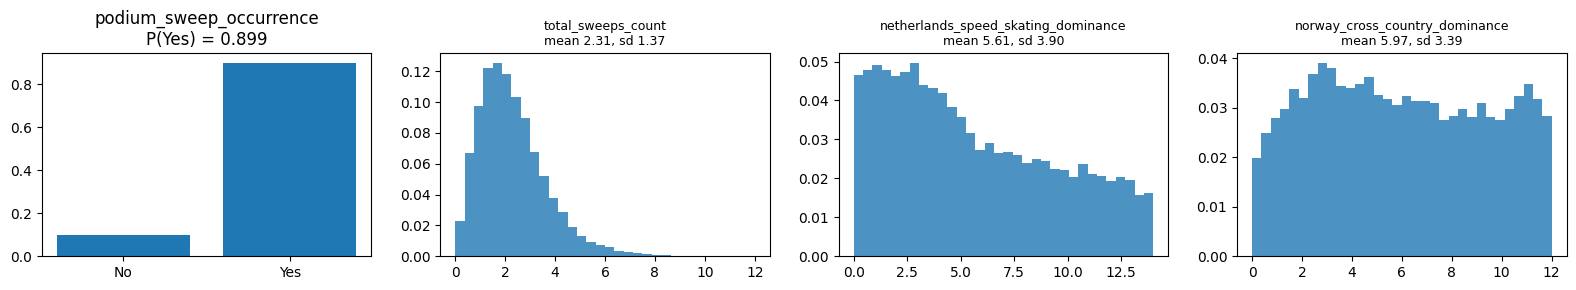

podium_sweep_occurrence                  {'mean': 0.8988, 'std': np.float64(0.3015933686273622), 'median': 1.0, 'q10': 0.0, 'q90': 1.0}
total_sweeps_count                       {'mean': np.float64(2.30679375), 'std': np.float64(1.3700745079961665), 'median': 2.0807830308146897, 'q10': 0.7876923076923077, 'q90': 4.08267716535433}
netherlands_speed_skating_dominance      {'mean': np.float64(5.609187499999999), 'std': np.float64(3.902865195683433), 'median': 4.7919921875, 'q10': 0.9253950050968401, 'q90': 11.635163834951456}
norway_cross_country_dominance           {'mean': np.float64(5.969849999999999), 'std': np.float64(3.387135871942547), 'median': 5.794394435351882, 'q10': 1.4685929648241205, 'q90': 10.815880989180833}


In [4]:
marginals = builder.get_all_marginals()
cont = [v.name for v in variables if isinstance(v, ContinuousVariable)]

fig, axes = plt.subplots(1, len(cont) + 1, figsize=(4 * (len(cont) + 1), 3))
axes[0].bar(["No", "Yes"], [1 - dist.probability, dist.probability], color="C0")
axes[0].set_title(f"{TARGET}\nP(Yes) = {dist.probability:.3f}")
for ax, name in zip(axes[1:], cont):
    m = marginals[name]
    ax.bar(m.bin_centers, m.bin_probabilities, width=m.bin_widths, color="C0", alpha=0.8)
    ax.set_title(f"{name}\nmean {m.mean():.2f}, sd {m.std():.2f}", fontsize=9)
plt.tight_layout()
plt.show()

for name, m in marginals.items():
    print(f"{name:<40s} {m.summary()}")

### Joint structure

The estimates only constrain a handful of (conditional) expectations; maxent
fills in everything else as flat/independent as those constraints allow. The
conditional estimates induce visible dependence between the count variables and
the sweep indicator.

correlations with the target:
  corr(podium_sweep_occurrence, total_sweeps_count) = +0.13
  corr(podium_sweep_occurrence, netherlands_speed_skating_dominance) = +0.21
  corr(podium_sweep_occurrence, norway_cross_country_dominance) = +0.29


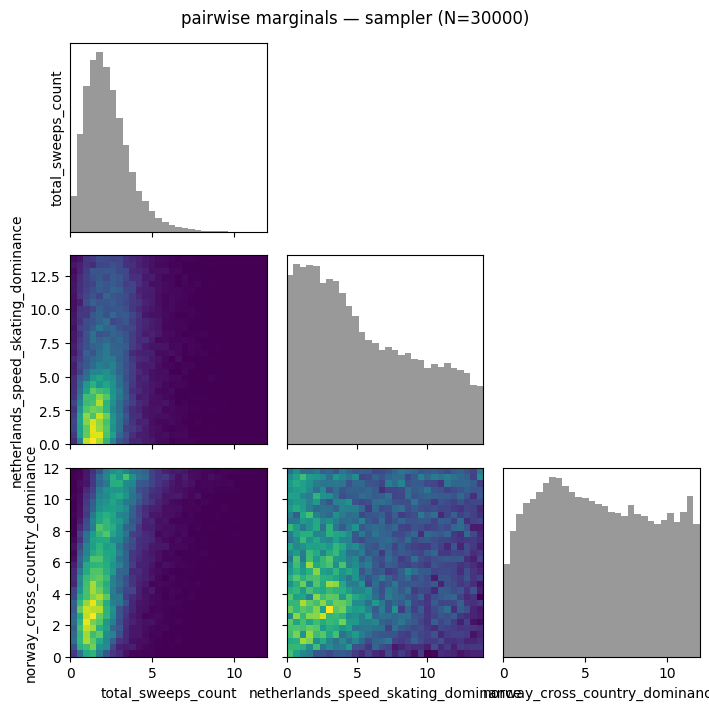

In [5]:
sites = [builder.var_name_to_idx[n] for n in cont]
_ = plot_pairwise(builder.model, info["params"], sites=sites, names=cont,
                  n_samples=30000, seed=7, bins=30)

s = builder.sample_dict(50000)
X = np.stack([s[v.name] for v in variables], axis=1)
C = np.corrcoef(X.T)
print("correlations with the target:")
for v in variables[1:]:
    print(f"  corr({TARGET}, {v.name}) = {C[0, builder.var_name_to_idx[v.name]]:+.2f}")

### Robust mode

LLM estimate sets are routinely *inconsistent*. With `robust=True` every
estimate becomes an `onoff` constraint: a learnable Bernoulli credence
(prior `1 - p_broken = 0.95`) that the optimizer can lower — convicting the
estimate at a KL price of `-log(p_broken)` — instead of letting one bad number
drag the whole joint. Credences are read back per estimate in the report.

In [6]:
rb = DistributionBuilder(variables, estimates, robust=True)
rdist, rinfo = rb.build(target_variable=TARGET, steps=2000, n_samples=2048)
print(f"P(podium sweep) = {rdist.probability:.3f}   entropy = {rinfo['entropy']:.2f} nats\n")
for r in sorted(rinfo["report"], key=lambda r: r["credence"]):
    print(f"credence {r['credence']:.3f}  err {r['error']:+.3f}   {r['estimate']}")

P(podium sweep) = 0.902   entropy = 5.91 nats

credence 0.922  err +0.354   E[total_sweeps_count] = 1.9
credence 0.945  err -0.480   E[norway_cross_country_dominance | podium_sweep_occurrence = False] = 3.5
credence 0.946  err +0.069   P(total_sweeps_count > 0.5) = 0.88
credence 0.946  err +0.057   P(total_sweeps_count > 2.0 | norway_cross_country_dominance > 5.0, netherlands_speed_skating_dominance > 5.0) = 0.72
credence 0.947  err -0.150   E[total_sweeps_count | norway_cross_country_dominance > 8.0] = 3.2
credence 0.948  err +0.021   P(podium_sweep_occurrence = True) = 0.88
credence 0.948  err -0.049   P(total_sweeps_count > 4.0) = 0.15
credence 0.948  err -0.136   E[norway_cross_country_dominance] = 6.0
credence 0.948  err +0.101   E[netherlands_speed_skating_dominance] = 5.5
credence 0.949  err +0.019   P(podium_sweep_occurrence = True | netherlands_speed_skating_dominance > 7.0) = 0.96


### Notes

- **Knobs.** `prob_sd=0.05` / `value_rel_sd=0.05` set the belief widths
  (constraint weights `1/(2sd^2)`; expectation widths are a fraction of the
  variable's span so mixed domains stay unit-free). `sharpness=20` is the
  soft-indicator slope in span-normalized units — sharpen it (and raise
  `n_samples`) if the hard-indicator report drifts from the soft loss.
- **Conditioning budget.** A conditional estimate's gradient signal comes from
  the `n_samples * p_cond` samples that hit its conditioning event. Here the
  events sit at `p_cond ~ 0.1-0.4`; a much rarer event would need a bigger
  batch (watch `p_cond` in the report).
- **Consistency, not just fit.** Residuals under maxent are informative: an
  estimate that stays off-target at convergence is being outvoted by the other
  estimates, and `robust=True` turns that tension into an explicit per-estimate
  credence.
- **Parity.** `build(target)` mirrors `maxent_smm.DistributionBuilder`, so the
  metaculus eval loop can swap solvers by changing the import and the
  `build`/`run_solver` call.